# DMI quick example notebook

This notebook shows a minimal workflow to run the Dipole Mode Index (DMI) diagnostic and generate index and regression plots.

The only required imports are `DMI` and `PlotDMI` from `aqua.diagnostics.teleconnections`.

In [1]:
from aqua.diagnostics.teleconnections import DMI, PlotDMI

/LUMI_TYKKY_z8HRM6k/miniforge/envs/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define dataset and reference

As in the ENSO notebook, we define one model dataset and one reference (ERA5).

In [2]:
dataset_dict = {
    "catalog": "climatedt-phase1",
    "model": "IFS-NEMO",
    "exp": "historical-1990",
    "source": "lra-r100-monthly",
}
obs_dict = {
    "catalog": "obs",
    "model": "ERA5",
    "exp": "era5",
    "source": "monthly",
}
common_dict = {"loglevel": "INFO"}

In [3]:
dmi_dataset = DMI(**dataset_dict, **common_dict)
dmi_obs = DMI(**obs_dict, **common_dict)

## Retrieve data and compute index

DMI computes anomalies over two Indian Ocean regions and then takes their difference.

In [4]:
dmi_dataset.retrieve()
dmi_obs.retrieve()

dmi_dataset.compute_index()
dmi_obs.compute_index()

dmi_dataset.index
dmi_obs.index

2026-06-30 23:41:16 :: DMI :: INFO     -> Retrieving data for DMI index calculation.
/LUMI_TYKKY_z8HRM6k/miniforge/envs/env1/lib/python3.12/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/LUMI_TYKKY_z8HRM6k/miniforge/envs/env1/lib/python3.12/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
2026-06-30 23:41:16 :: ConfigPath :: INFO     -> IFS-NEMO_historical-1990_lra-r100-monthly triplet found in in climatedt-phase1!
2026-06-30 23:41:16 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-06-30 23:41:16 :: FixerConfigure :: INFO     -> No fixer_name found, only convention will be applied
2026-06-30 23:41:17 :: Reader :: INFO     -> Grid metadata is lon-lat-r100
2026-06-30 23:41:17 :: Regridder :: INFO     -> Grid name:

<xarray.DataArray 'DMI index' (time: 1020)> Size: 8kB
array([ 0.638095  ,  0.12918598,  0.04490366, ..., -0.48925124,
       -0.37683234, -0.31293772], shape=(1020,))
Coordinates:
  * time     (time) datetime64[us] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
    month    (time) int64 8kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Attributes: (12/14)
    long_name:       DMI index
    units:           K
    code:            34
    table:           128
    paramId:         262101
    shortName:       tos
    ...              ...
    AQUA_exp:        era5
    AQUA_source:     monthly
    AQUA_catalog:    obs
    AQUA_version:    1.0.0a5
    AQUA_startdate:  1940-01-01
    AQUA_enddate:    2024-12-01

In [5]:
dmi_dataset.save_netcdf(dmi_dataset.index, diagnostic="dmi", diagnostic_product="index")
dmi_obs.save_netcdf(dmi_obs.index, diagnostic="dmi", diagnostic_product="index")

2026-06-30 23:42:57 :: create_folder :: INFO     -> Creating folder ./netcdf
2026-06-30 23:42:57 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/dmi.index.climatedt-phase1.IFS-NEMO.historical-1990.r1.nc
2026-06-30 23:42:57 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-06-30 23:42:57 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/dmi.index.obs.ERA5.era5.r1.nc


## Regression maps

By default, regression is computed on the same variable used for the index (`tos`).

In [6]:
reg_data = dmi_dataset.compute_regression(season="annual")
reg_obs = dmi_obs.compute_regression(season="annual")

dmi_dataset.save_netcdf(reg_data, diagnostic="dmi", diagnostic_product="regression")
dmi_obs.save_netcdf(reg_obs, diagnostic="dmi", diagnostic_product="regression")

2026-06-30 23:42:58 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-06-30 23:42:58 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/dmi.regression.climatedt-phase1.IFS-NEMO.historical-1990.r1.nc
2026-06-30 23:42:58 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-06-30 23:43:45 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/dmi.regression.obs.ERA5.era5.r1.nc


## Plot index and regression

Load data before plotting maps to avoid cartopy+dask issues.

2026-06-30 23:45:19 :: create_folder :: INFO     -> Folder ./png already exists
2026-06-30 23:45:20 :: OutputSaver :: INFO     -> Saved PNG: ./png/dmi.index.climatedt-phase1.IFS-NEMO.historical-1990.r1.obs.ERA5.era5.png
2026-06-30 23:45:20 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-06-30 23:45:20 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/dmi.index.climatedt-phase1.IFS-NEMO.historical-1990.r1.obs.ERA5.era5.pdf
2026-06-30 23:45:20 :: create_folder :: INFO     -> Folder ./svg already exists
2026-06-30 23:45:21 :: OutputSaver :: INFO     -> Saved SVG: ./svg/dmi.index.climatedt-phase1.IFS-NEMO.historical-1990.r1.obs.ERA5.era5.svg


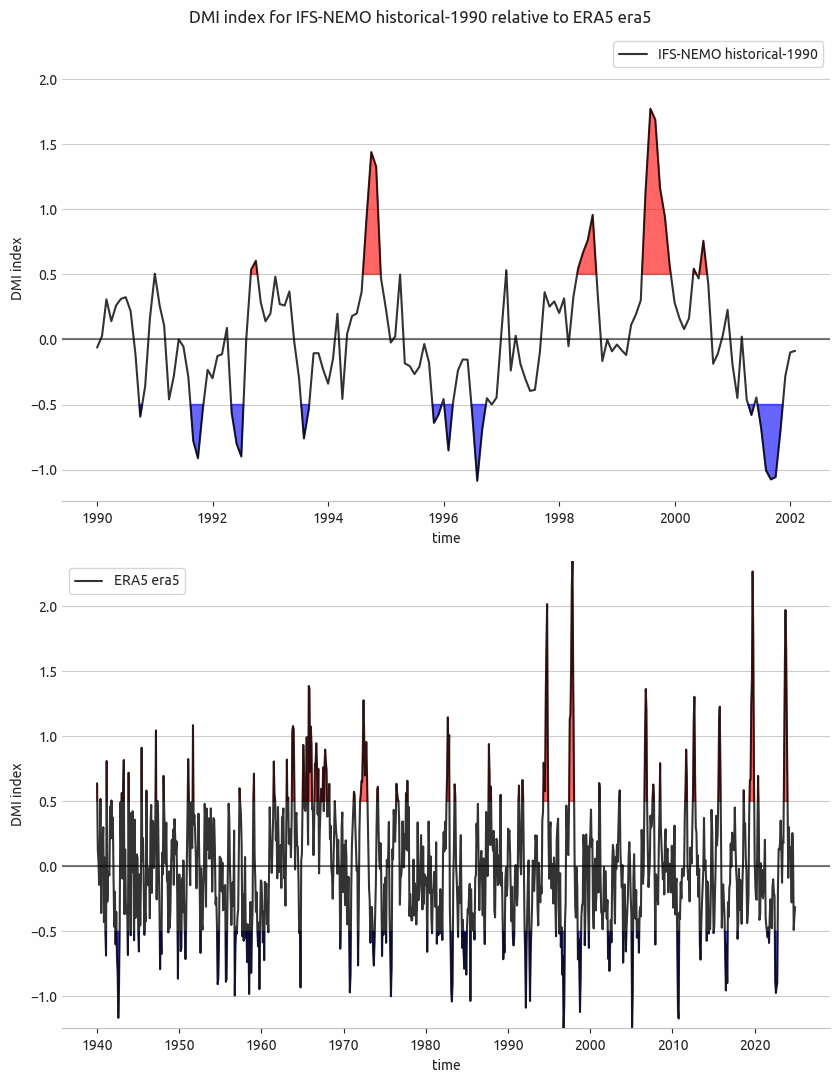

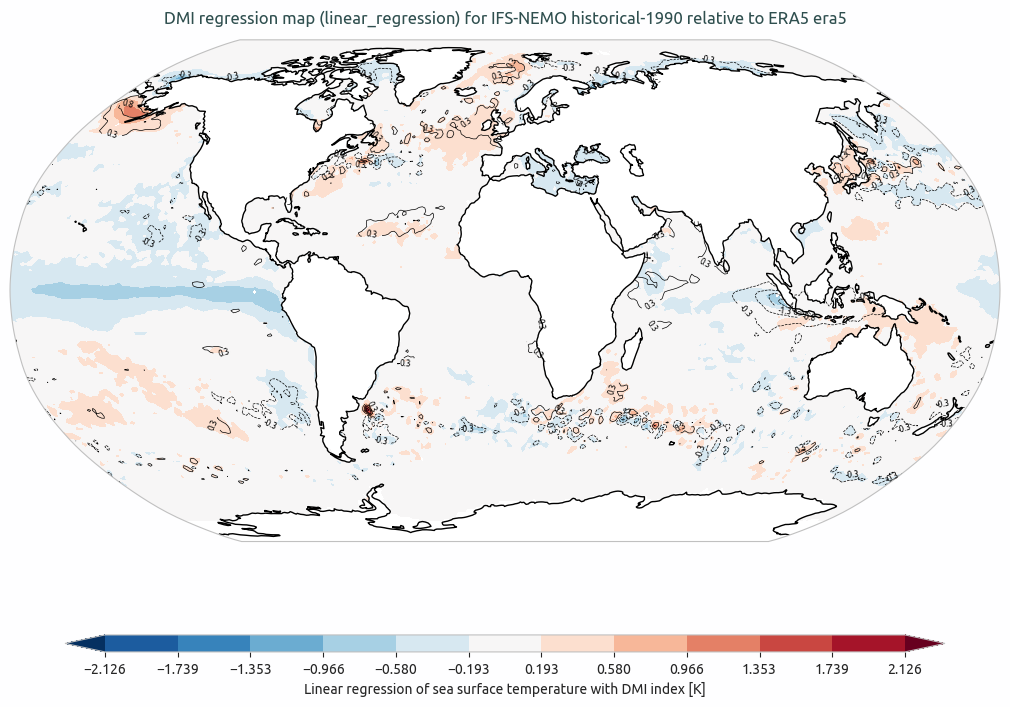

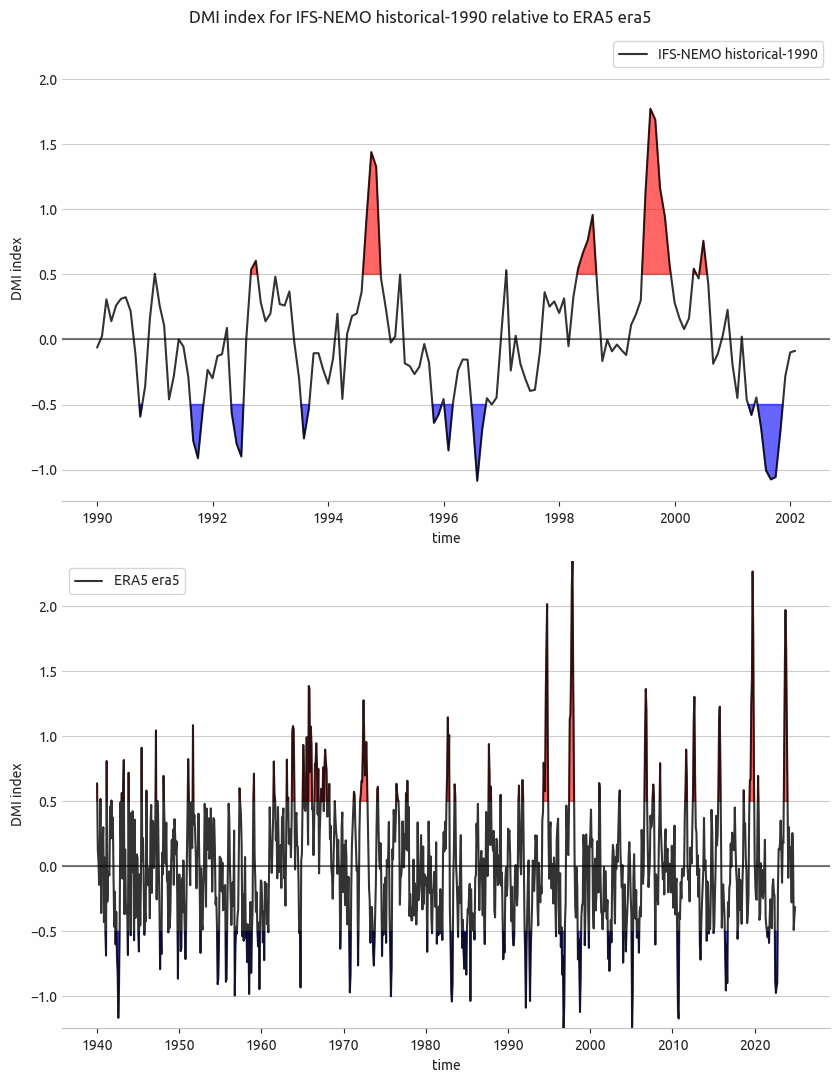

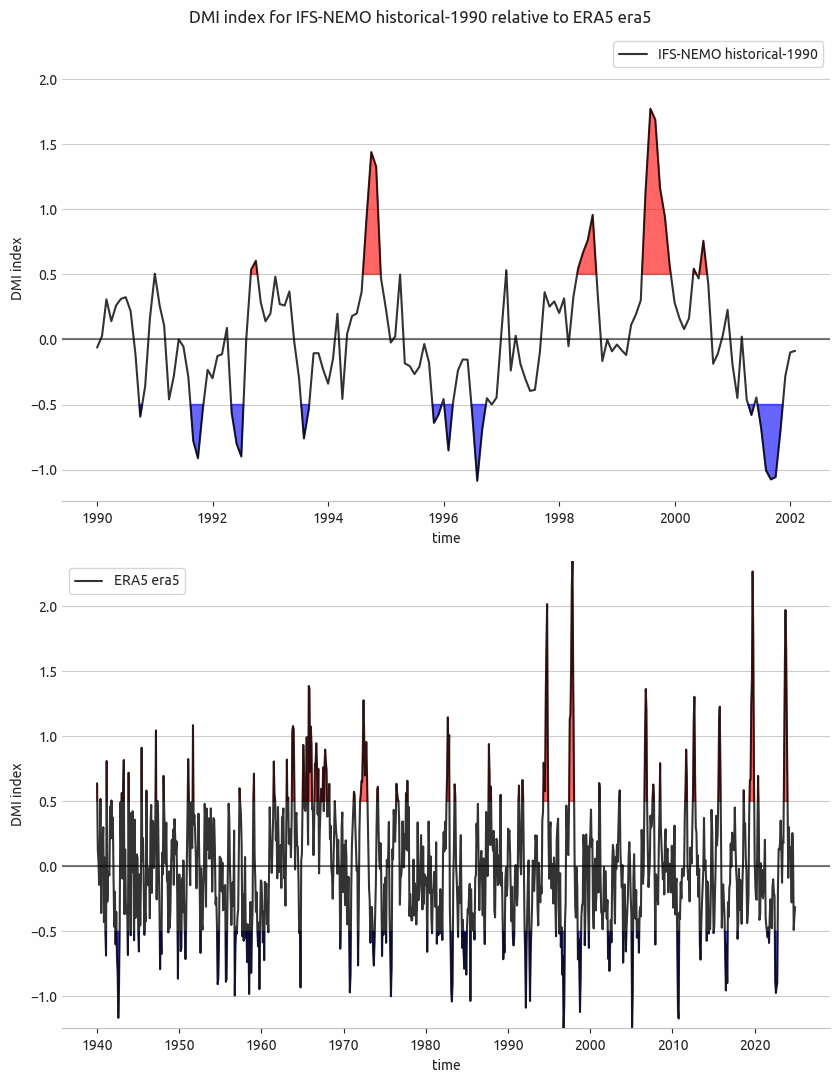

In [10]:
%matplotlib inline
plot = PlotDMI(indexes=dmi_dataset.index, ref_indexes=dmi_obs.index, loglevel="INFO")

fig_index, _ = plot.plot_index()
description_index = plot.set_index_description()
plot.save_plot(fig_index, diagnostic_product="index", metadata={"description": description_index})

2026-06-30 23:45:44 :: create_folder :: INFO     -> Folder ./png already exists
2026-06-30 23:45:45 :: OutputSaver :: INFO     -> Saved PNG: ./png/dmi.regression.climatedt-phase1.IFS-NEMO.historical-1990.r1.obs.ERA5.era5.png
2026-06-30 23:45:45 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-06-30 23:45:45 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/dmi.regression.climatedt-phase1.IFS-NEMO.historical-1990.r1.obs.ERA5.era5.pdf
2026-06-30 23:45:45 :: create_folder :: INFO     -> Folder ./svg already exists
2026-06-30 23:45:45 :: OutputSaver :: INFO     -> Saved SVG: ./svg/dmi.regression.climatedt-phase1.IFS-NEMO.historical-1990.r1.obs.ERA5.era5.svg


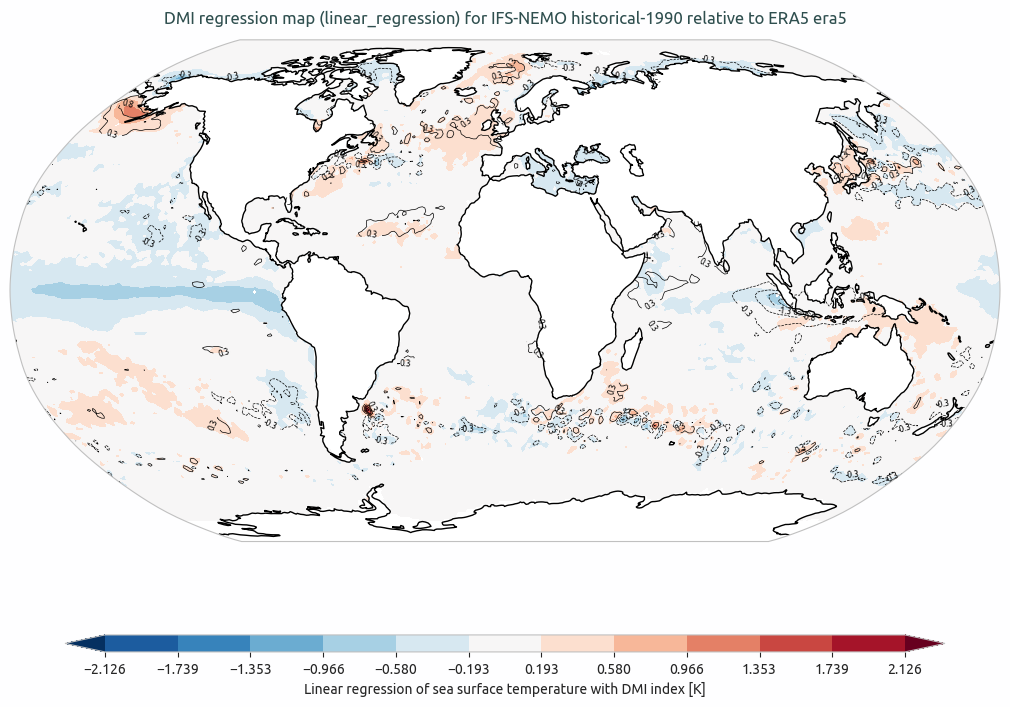

In [11]:
reg_data.load()
reg_obs.load()

fig_reg = plot.plot_maps(maps=[reg_data], ref_maps=[reg_obs], statistic="regression")
description_reg = plot.set_map_description(maps=[reg_data], ref_maps=[reg_obs], statistic="regression")
plot.save_plot(fig_reg, diagnostic_product="regression", metadata={"description": description_reg})